# Loss Chasing Behavior Analysis

Organizes each player's bets by previous play date/outcome, then tests and visualizes whether players increase their bet size after a loss (loss chasing).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from poker_coach.config import GRAPE_SODA, MUTED_TEAL, BUSTABIT_DATA_FILE

sns.set_theme(style='darkgrid')


In [2]:
df = pd.read_csv(BUSTABIT_DATA_FILE, parse_dates=['PlayDate'])
df['Won'] = df['CashedOut'].notna()   # missing CashedOut = player busted (lost)
print(f"{len(df)} bets from {df['Username'].nunique()} players")

50000 bets from 4149 players


Organize the data to sort by each player's previous play date and gambling behaviors.

In [3]:
df.sort_values(['Username', 'PlayDate']).reset_index(drop=True) #track the players' behavior throughout each day they played. 
#created these to keep track of past times they bet and won
df['PrevBet'] = df.groupby('Username')['Bet'].shift(1)
df['PrevWon'] = df.groupby('Username')['Won'].shift(1)
# Is this bet bigger then the last one they did?
df['BetIncreased'] = df['Bet'] > df['PrevBet']
seq_df = df.dropna(subset=['PrevWon', 'PrevBet']).copy() #no need to keep the first ever time user betted since there are no history before
seq_df['PrevOutcome'] = seq_df['PrevWon'].map({True: 'After Win', False: 'After Loss'})

print(f"There are {len(seq_df):,} sequential bet that exhibit loss chasing like behaviors")

There are 45,851 sequential bet that exhibit loss chasing like behaviors


Bar chart showing loss chassing behaviors

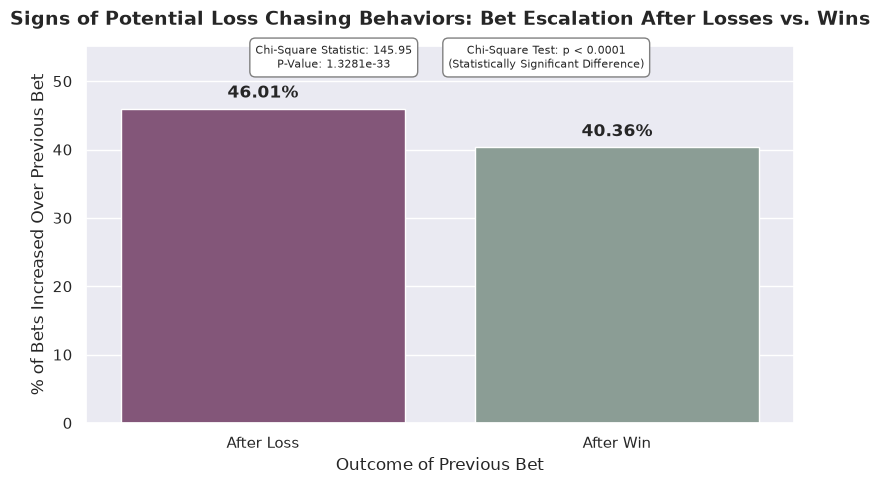

Chi-Square Statistic: 145.95
P-Value: 1.3281e-33


In [4]:
#table that counts the bet as they increase and bet previous outcome
Betting_Vs_Outcome_table = pd.crosstab(seq_df['PrevOutcome'], seq_df['BetIncreased'])
chi2, p_val, dof, expected = stats.chi2_contingency(Betting_Vs_Outcome_table)
prop_df = seq_df.groupby('PrevOutcome')['BetIncreased'].mean().reset_index()
prop_df['Percentage'] = prop_df['BetIncreased'] * 100
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=prop_df, x='PrevOutcome', y='Percentage', hue='PrevOutcome', palette=[ GRAPE_SODA, MUTED_TEAL], order=['After Loss', 'After Win'], legend=False)

plt.title('Signs of Potential Loss Chasing Behaviors: Bet Escalation After Losses vs. Wins', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('% of Bets Increased Over Previous Bet', fontsize=12)
plt.xlabel('Outcome of Previous Bet', fontsize=12)
plt.ylim(0, max(prop_df['Percentage']) * 1.2)

# Annotate percentages on bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', xytext=(0, 5), textcoords='offset points')

# Annotate Chi-Square p-value directly on the chart
p_text = f"p < 0.0001" if p_val < 0.0001 else f"p = {p_val:.4f}"
plt.text(0.8, max(prop_df['Percentage']) * 1.13, f"Chi-Square Test: {p_text}\n(Statistically Significant Difference)", 
         ha='center',fontsize=8, bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray'))

p_val_text = f"Chi-Square Statistic: {chi2:.2f}\nP-Value: {p_val:.4e}"
plt.text(0.2, max(prop_df['Percentage']) * 1.13, p_val_text, 
         ha='center',fontsize=8, bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray'))

plt.tight_layout()
plt.show()

print(p_val_text)